In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [126]:
! pip install opendatasets

In [127]:
import opendatasets as od

In [128]:
od.download('https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/data')

Skipping, found downloaded files in "./personal-key-indicators-of-heart-disease" (use force=True to force download)


In [129]:
df = pd.read_csv('/content/personal-key-indicators-of-heart-disease/2022/heart_2022_with_nans.csv')

In [130]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

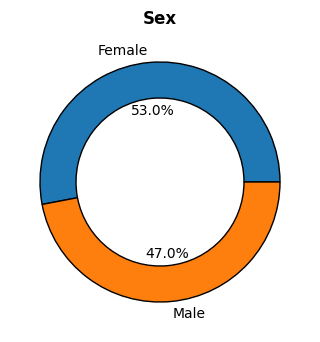

In [132]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_sex = df['Sex'].value_counts()

axes.pie(df_count_sex,
         labels = df_count_sex.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%')

axes.set_title('Sex', fontweight = 'bold')

plt.show()

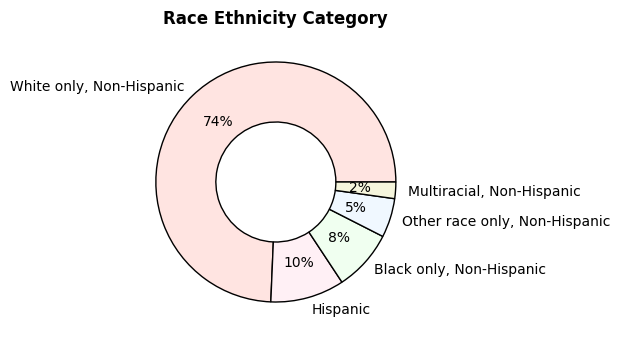

In [133]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_race_ethnicity_category = df['RaceEthnicityCategory'].value_counts()

axes.pie(df_count_race_ethnicity_category,
         labels = df_count_race_ethnicity_category.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.5},
         autopct = '%1.0f%%',
         pctdistance = 0.7,
         colors = ['#FFE4E1', '#FFF0F5', '#F0FFF0', '#F0F8FF', '#F5F5DC'])

axes.set_title('Race Ethnicity Category', fontweight = 'bold')

plt.show()

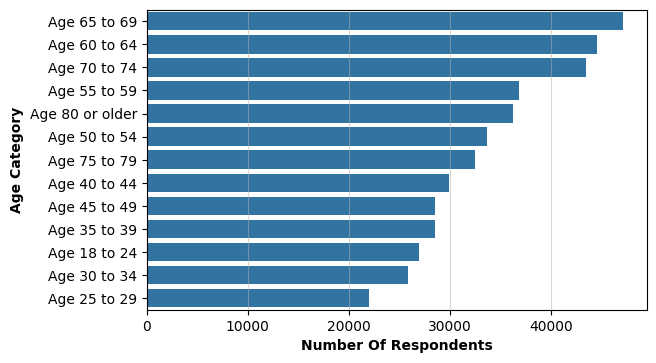

In [134]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_age_category = df['AgeCategory'].value_counts()

sns.barplot(df_count_age_category, orient = 'y')

axes.set_xlabel('Number Of Respondents', fontweight = 'bold')
axes.set_ylabel('Age Category', fontweight = 'bold')

axes.grid(axis = 'x', alpha = 0.5)

plt.show()

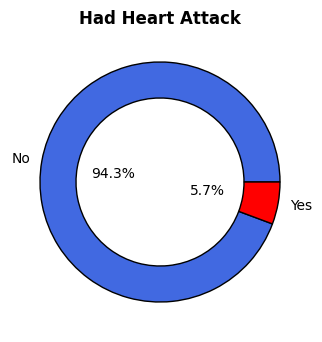

In [135]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_had_heart_attack = df['HadHeartAttack'].value_counts()

axes.pie(df_count_had_heart_attack,
         labels = df_count_had_heart_attack.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%',
         pctdistance = 0.4,
         colors = ['royalblue', 'red'])

axes.set_title('Had Heart Attack', fontweight = 'bold')

plt.show()

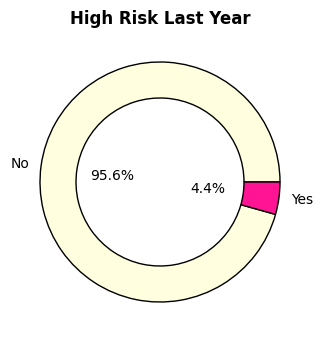

In [136]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_high_risk_last_year = df['HighRiskLastYear'].value_counts()

axes.pie(df_count_high_risk_last_year,
         labels = df_count_high_risk_last_year.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%',
         pctdistance = 0.4,
         colors = ['#FFFFE0', '#FF1493'])

axes.set_title('High Risk Last Year', fontweight = 'bold')

plt.show()

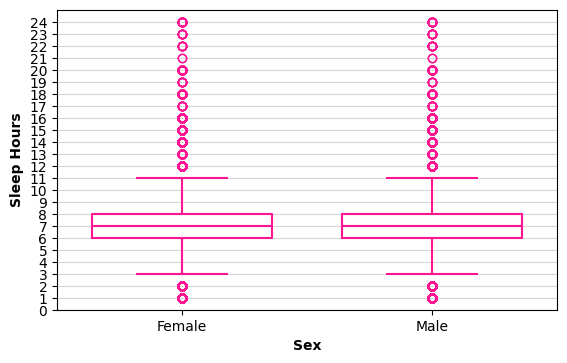

In [137]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

sns.boxplot(data = df, x = 'Sex', y = 'SleepHours', fill = False, gap = .1, color = '#FF1493')

axes.set_xlabel('Sex', fontweight = 'bold')
axes.set_ylabel('Sleep Hours', fontweight = 'bold')
axes.set_ylim(0, 25)
axes.yaxis.set_ticks(np.arange(0, 25))

axes.grid(axis = 'y', alpha = 0.5)

plt.show()

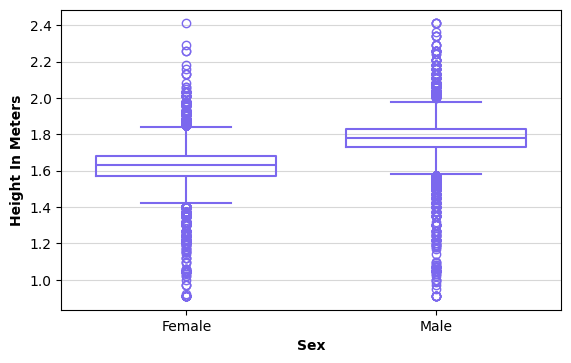

In [138]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

sns.boxplot(data = df, x = 'Sex', y = 'HeightInMeters', fill = False, gap = .1, color = '#7B68EE')

axes.set_xlabel('Sex', fontweight = 'bold')
axes.set_ylabel('Height In Meters', fontweight = 'bold')

axes.grid(axis = 'y', alpha = 0.5)

plt.show()

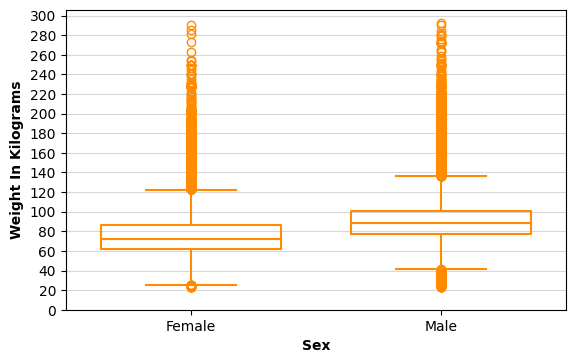

In [139]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

sns.boxplot(data = df, x = 'Sex', y = 'WeightInKilograms', fill = False, gap = .1, color = '#FF8C00')

axes.set_xlabel('Sex', fontweight = 'bold')
axes.set_ylabel('Weight In Kilograms', fontweight = 'bold')
axes.yaxis.set_ticks(np.arange(0, 310, 20))

axes.grid(axis = 'y', alpha = 0.5)

plt.show()

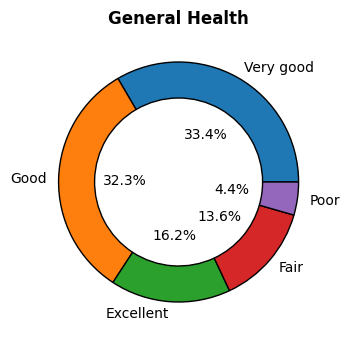

In [140]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_general_health = df['GeneralHealth'].value_counts()

axes.pie(df_count_general_health,
         labels = df_count_general_health.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%',
         pctdistance = 0.45)

axes.set_title('General Health', fontweight = 'bold')

plt.show()

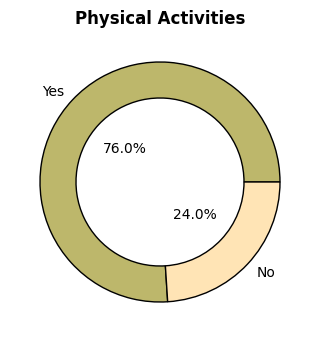

In [141]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_physical_activities = df['PhysicalActivities'].value_counts()

axes.pie(df_count_physical_activities,
         labels = df_count_physical_activities.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%',
         pctdistance = 0.4,
         colors = ['#BDB76B', '#FFE4B5'])

axes.set_title('Physical Activities', fontweight = 'bold')

plt.show()

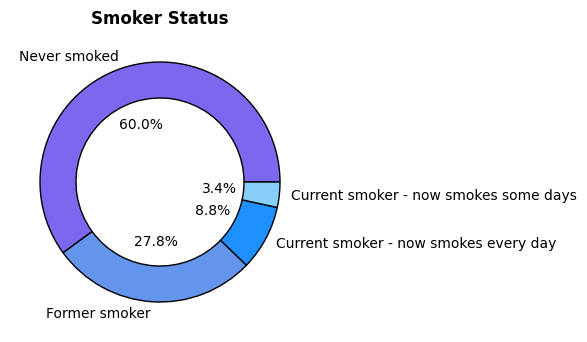

In [142]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_smoker_status = df['SmokerStatus'].value_counts()

axes.pie(df_count_smoker_status,
         labels = df_count_smoker_status.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%',
         pctdistance = 0.5,
         colors = ['#7B68EE', '#6495ED', '#1E90FF', '#87CEFA'])

axes.set_title('Smoker Status', fontweight = 'bold')

plt.show()

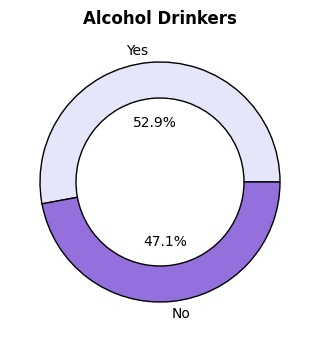

In [143]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_alcohol_drinkers = df['AlcoholDrinkers'].value_counts()

axes.pie(df_count_alcohol_drinkers,
         labels = df_count_alcohol_drinkers.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%',
         pctdistance = 0.5,
         colors = ['#E6E6FA', '#9370DB'])

axes.set_title('Alcohol Drinkers', fontweight = 'bold')

plt.show()

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

In [145]:
del df['State']
del df['RemovedTeeth']
del df['ECigaretteUsage']
del df['HeightInMeters']
del df['WeightInKilograms']

In [146]:
df.isnull().sum()

,0
Sex,0
GeneralHealth,1198
PhysicalHealthDays,10927
MentalHealthDays,9067
LastCheckupTime,8308
PhysicalActivities,1093
SleepHours,5453
HadHeartAttack,3065
HadAngina,4405
HadStroke,1557


In [147]:
df.shape

(445132, 35)

In [148]:
df.dropna(axis = 0, how = 'any', inplace = True)

In [149]:
df.shape

(250472, 35)

In [150]:
df.isnull().sum()

,0
Sex,0
GeneralHealth,0
PhysicalHealthDays,0
MentalHealthDays,0
LastCheckupTime,0
PhysicalActivities,0
SleepHours,0
HadHeartAttack,0
HadAngina,0
HadStroke,0


In [151]:
df = pd.get_dummies(df, drop_first = True)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250472 entries, 4 to 445130
Data columns (total 61 columns):
 #   Column                                                                   Non-Null Count   Dtype  
---  ------                                                                   --------------   -----  
 0   PhysicalHealthDays                                                       250472 non-null  float64
 1   MentalHealthDays                                                         250472 non-null  float64
 2   SleepHours                                                               250472 non-null  float64
 3   BMI                                                                      250472 non-null  float64
 4   Sex_Male                                                                 250472 non-null  bool   
 5   GeneralHealth_Fair                                                       250472 non-null  bool   
 6   GeneralHealth_Good                                               

In [153]:
df_heat = df[['HadHeartAttack_Yes', 'PhysicalHealthDays', 'MentalHealthDays',
              'SleepHours', 'BMI', 'PhysicalActivities_Yes',
              'DifficultyWalking_Yes', 'AlcoholDrinkers_Yes', 'HighRiskLastYear_Yes']].corr()

<Axes: >

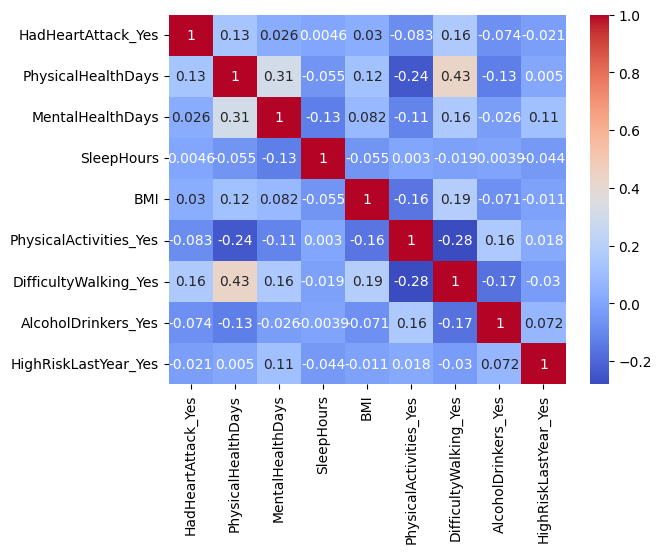

In [154]:
sns.heatmap(df_heat, annot = True, cmap = 'coolwarm')

In [155]:
X = df.drop(columns = ['HadHeartAttack_Yes'])

In [156]:
y = df['HadHeartAttack_Yes']

In [157]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True)

In [158]:
model = LogisticRegression(max_iter = 10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [159]:
prediction = (model.predict_proba(X_test)[:, 1] >= 0.115).astype(int)

In [160]:
print(confusion_matrix(y_test, prediction))

[[44353  2947]
 [ 1152  1643]]


In [161]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

       False       0.97      0.94      0.96     47300
        True       0.36      0.59      0.44      2795

    accuracy                           0.92     50095
   macro avg       0.67      0.76      0.70     50095
weighted avg       0.94      0.92      0.93     50095



In [162]:
fpr, tpr, _ = roc_curve(y_test, prediction)

In [163]:
roc_auc = auc(fpr, tpr)

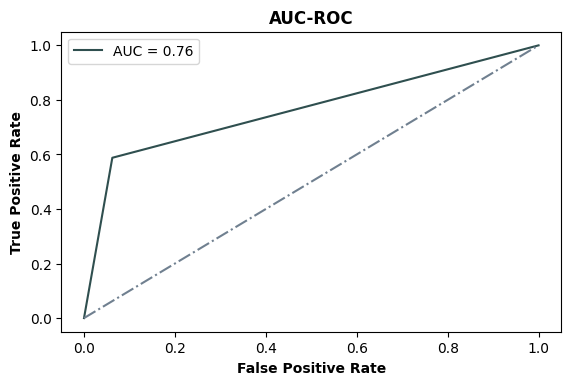

In [164]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

axes.plot(fpr, tpr, label = f'AUC = {roc_auc:.2f}', color = '#2F4F4F')

axes.plot([0, 1], [0, 1], color = '#708090', linestyle = '-.')

axes.set_xlabel('False Positive Rate', fontweight = 'bold')
axes.set_ylabel('True Positive Rate', fontweight = 'bold')
axes.set_title('AUC-ROC', fontweight = 'bold')

plt.legend()

plt.show()